# Overfitting

Para medir overfitting se debe comparar el desempeño del modelo en train y en test:

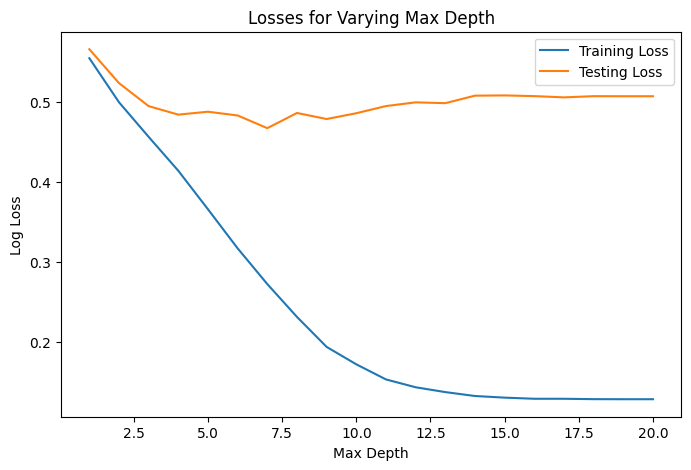

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt

# Load the dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
data = pd.read_csv(url, names=names)
X, y = data.iloc[:, :-1], data.iloc[:, -1]

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Vary max_depth hyperparameter
max_depths = list(range(1, 21))
train_losses_depth = []
test_losses_depth = []

for max_depth in max_depths:
    rf = RandomForestClassifier(n_estimators=100, max_depth=max_depth, random_state=42)
    rf.fit(X_train, y_train)
    
    train_proba = rf.predict_proba(X_train)
    test_proba = rf.predict_proba(X_test)
    
    train_loss = log_loss(y_train, train_proba)
    test_loss = log_loss(y_test, test_proba)
    
    train_losses_depth.append(train_loss)
    test_losses_depth.append(test_loss)

# Plot the training and testing losses for max_depth
fig, ax1 = plt.subplots(1, 1, figsize=(8, 5))

ax1.plot(max_depths, train_losses_depth, label="Training Loss")
ax1.plot(max_depths, test_losses_depth, label="Testing Loss")
ax1.set_xlabel("Max Depth")
ax1.set_ylabel("Log Loss")
ax1.legend()
ax1.set_title("Losses for Varying Max Depth")

plt.show()


# Learning rates

Entre más alto el learning rate, más rápido converge el algoritmo pero no necesariamente llega al óptimo:

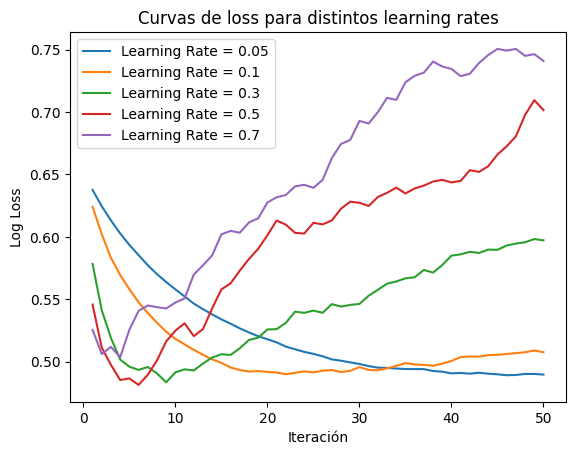

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import xgboost as xgb
import matplotlib.pyplot as plt

# Cargar dataset Pima Indians Diabetes
# Variables:
#   preg: número de embarazos
#   plas: concentración de glucosa en plasma (test de tolerancia oral, 2 horas)
#   pres: presión arterial diastólica (mm Hg)
#   skin: grosor del pliegue cutáneo del tríceps (mm)
#   test: insulina sérica a las 2 horas (mu U/ml)
#   mass: índice de masa corporal (kg/m²)
#   pedi: función de pedigrí de diabetes (score de riesgo genético)
#   age:  edad (años)
#   class: 0 = sin diabetes, 1 = con diabetes
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
data = pd.read_csv(url, names=names)
X, y = data.iloc[:, :-1], data.iloc[:, -1]

# Dividir en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar XGBoost con distintos learning rates (sin early stopping, para comparar las 50 iteraciones completas)
learning_rates = [0.05, 0.1, 0.3, 0.5, 0.7]
loss_history = {}

for lr in learning_rates:
    model = xgb.XGBClassifier(
        max_depth=3, learning_rate=lr, n_estimators=50,
        eval_metric='logloss', random_state=42
    )
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    
    loss_history[lr] = model.evals_result()['validation_0']['logloss']

# Graficar las curvas de loss para cada learning rate
for lr, losses in loss_history.items():
    plt.plot(range(1, len(losses) + 1), losses, label=f"Learning Rate = {lr}")

plt.xlabel("Iteración")
plt.ylabel("Log Loss")
plt.legend()
plt.title("Curvas de loss para distintos learning rates")
plt.show()

# Early Stopping en XGBoost

En vez de definir un número fijo de iteraciones (árboles), **early stopping** detiene el entrenamiento automáticamente cuando el modelo deja de mejorar en el conjunto de validación. Esto:

- Previene overfitting sin necesidad de calibrar `n_estimators` manualmente
- Ahorra tiempo de entrenamiento
- Es la práctica estándar en producción con XGBoost

Sin early stopping: 500 árboles (todos usados)
Con early stopping (patience=20):
  Mejor iteración:        22
  Iteraciones ejecutadas:  42 (siguió 20 más sin mejorar, y paró)
  Mejor logloss en test:   0.5020


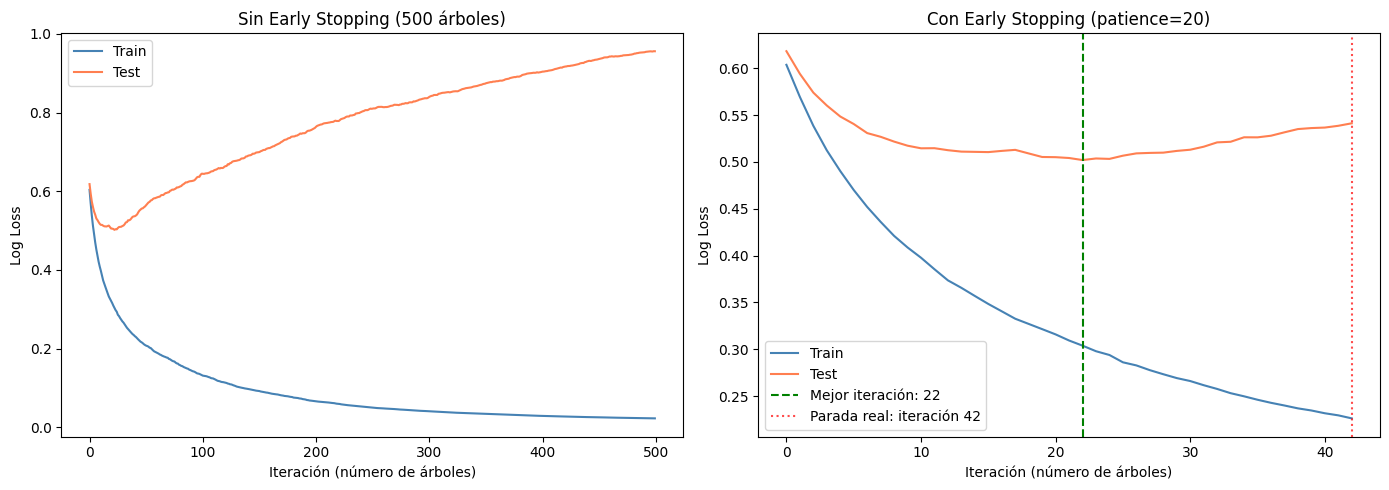


A la izquierda: sin early stopping, el modelo sigue entrenando aunque el test loss sube (overfitting).
A la derecha: early stopping espera 20 iteraciones sin mejora y luego para.
La línea verde marca la mejor iteración. La línea roja marca dónde paró realmente.
El modelo final usa los pesos de la mejor iteración (línea verde), no de la última.


In [3]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt

# Cargar datos
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
data = pd.read_csv(url, names=names)
X, y = data.iloc[:, :-1], data.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

ES_ROUNDS = 20

# Entrenar SIN early stopping (muchas iteraciones)
model_no_es = xgb.XGBClassifier(n_estimators=500, max_depth=5, learning_rate=0.1,
                                 random_state=42, eval_metric='logloss')
model_no_es.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)

# Entrenar CON early stopping
model_es = xgb.XGBClassifier(n_estimators=500, max_depth=5, learning_rate=0.1,
                              random_state=42, eval_metric='logloss',
                              early_stopping_rounds=ES_ROUNDS)
model_es.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)

total_iter = model_es.best_iteration + ES_ROUNDS

print(f"Sin early stopping: {model_no_es.n_estimators} árboles (todos usados)")
print(f"Con early stopping (patience={ES_ROUNDS}):")
print(f"  Mejor iteración:        {model_es.best_iteration}")
print(f"  Iteraciones ejecutadas:  {total_iter} (siguió {ES_ROUNDS} más sin mejorar, y paró)")
print(f"  Mejor logloss en test:   {model_es.best_score:.4f}")

# Graficar las curvas de loss
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sin early stopping
results_no_es = model_no_es.evals_result()
ax = axes[0]
ax.plot(results_no_es['validation_0']['logloss'], label='Train', color='steelblue')
ax.plot(results_no_es['validation_1']['logloss'], label='Test', color='coral')
ax.set_xlabel('Iteración (número de árboles)')
ax.set_ylabel('Log Loss')
ax.set_title(f'Sin Early Stopping ({model_no_es.n_estimators} árboles)')
ax.legend()

# Con early stopping
results_es = model_es.evals_result()
ax = axes[1]
ax.plot(results_es['validation_0']['logloss'], label='Train', color='steelblue')
ax.plot(results_es['validation_1']['logloss'], label='Test', color='coral')
ax.axvline(x=model_es.best_iteration, color='green', linestyle='--',
           label=f'Mejor iteración: {model_es.best_iteration}')
ax.axvline(x=total_iter, color='red', linestyle=':', alpha=0.7,
           label=f'Parada real: iteración {total_iter}')
ax.set_xlabel('Iteración (número de árboles)')
ax.set_ylabel('Log Loss')
ax.set_title(f'Con Early Stopping (patience={ES_ROUNDS})')
ax.legend()

plt.tight_layout()
plt.show()

print("\nA la izquierda: sin early stopping, el modelo sigue entrenando aunque el test loss sube (overfitting).")
print("A la derecha: early stopping espera 20 iteraciones sin mejora y luego para.")
print("La línea verde marca la mejor iteración. La línea roja marca dónde paró realmente.")
print("El modelo final usa los pesos de la mejor iteración (línea verde), no de la última.")

# Regularización y overfitting

En XGBoost, la función objetivo que se minimiza es:

$$\mathcal{L} = \sum_{i} l(y_i, \hat{y}_i) + \sum_{k} \Omega(f_k)$$

Donde $l$ es la loss (ej: log-loss) y $\Omega$ es el término de **regularización** que penaliza la complejidad de cada árbol $f_k$:

$$\Omega(f) = \gamma T + \frac{1}{2} \lambda \sum_{j=1}^{T} w_j^2$$

- $T$ = número de hojas del árbol
- $w_j$ = valor de predicción en la hoja $j$
- $\gamma$ (`gamma`) = penalización por cada hoja adicional (controla cuántas hojas tiene el árbol)
- $\lambda$ (`reg_lambda`) = **regularización L2** sobre los valores de las hojas

### ¿Qué hace la regularización L2 (`reg_lambda`)?

Penaliza predicciones **extremas** en las hojas. Sin regularización, una hoja con pocas observaciones puede tener un valor de predicción muy alto o muy bajo (overfitting a esas pocas observaciones). Con L2:

- Los valores de las hojas se **encojen** hacia cero (shrinkage)
- El modelo se vuelve más **conservador** — prefiere predicciones moderadas
- Esto reduce la varianza a costa de un poco más de sesgo

Es análogo a **Ridge Regression**: así como Ridge encoge los coeficientes $\beta$ hacia cero, `reg_lambda` encoge los valores de las hojas $w_j$ hacia cero.

### Otros parámetros de regularización en XGBoost

| Parámetro | Qué hace |
|---|---|
| `reg_lambda` (L2) | Encoge valores de las hojas hacia cero |
| `reg_alpha` (L1) | Igual, pero puede poner valores exactamente en cero (como Lasso) |
| `gamma` | Penaliza el número de hojas (poda implícita) |
| `max_depth` | Limita la profundidad directamente |
| `min_child_weight` | Mínimo de observaciones para crear una hoja |

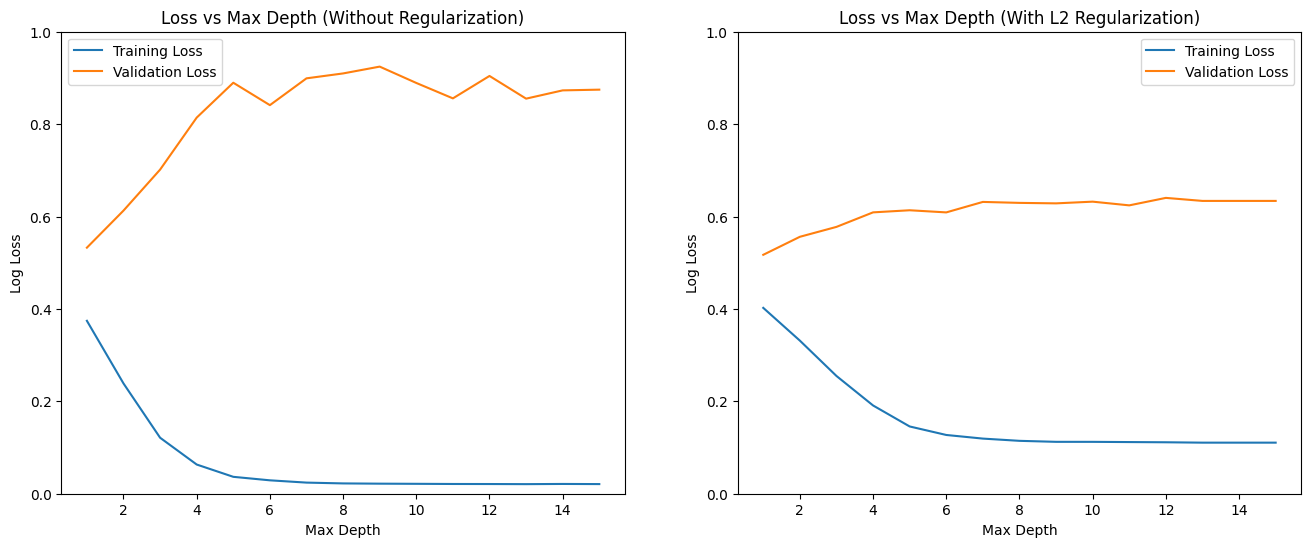

In [4]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt

# Load the dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
data = pd.read_csv(url, names=names)
X, y = data.iloc[:, :-1], data.iloc[:, -1]

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize lists to store training and validation losses
train_losses = []
val_losses = []

train_losses_reg = []
val_losses_reg = []

max_depths = list(range(1, 16))

for max_depth in max_depths:
    # Train XGBoost without regularization
    xgb_model = xgb.XGBClassifier(max_depth=max_depth, random_state=42, n_jobs=-1)
    xgb_model.fit(X_train, y_train)
    train_loss = log_loss(y_train, xgb_model.predict_proba(X_train))
    val_loss = log_loss(y_test, xgb_model.predict_proba(X_test))
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Train XGBoost with L2 regularization (reg_lambda)
    xgb_model_reg = xgb.XGBClassifier(max_depth=max_depth, reg_lambda=20, random_state=42, n_jobs=-1)
    xgb_model_reg.fit(X_train, y_train)
    train_loss_reg = log_loss(y_train, xgb_model_reg.predict_proba(X_train))
    val_loss_reg = log_loss(y_test, xgb_model_reg.predict_proba(X_test))
    train_losses_reg.append(train_loss_reg)
    val_losses_reg.append(val_loss_reg)

# Plot the training and validation losses without regularization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(max_depths, train_losses, label="Training Loss")
ax1.plot(max_depths, val_losses, label="Validation Loss")
ax1.set_title("Loss vs Max Depth (Without Regularization)")
ax1.set_xlabel("Max Depth")
ax1.set_ylabel("Log Loss")
ax1.legend()
ax1.set_ylim(0, 1)  # Set the y-axis scale

# Plot the training and validation losses with L2 regularization (reg_lambda)
ax2.plot(max_depths, train_losses_reg, label="Training Loss")
ax2.plot(max_depths, val_losses_reg, label="Validation Loss")
ax2.set_title("Loss vs Max Depth (With L2 Regularization)")
ax2.set_xlabel("Max Depth")
ax2.set_ylabel("Log Loss")
ax2.legend()
ax2.set_ylim(0, 1)  # Set the y-axis scale

plt.show()


# Importancia de las variables y Shap values

Además de medir la importancia de las variables con `.feature_importances_`, los **SHAP values** permiten entender la contribución de cada variable a cada predicción individual:

/Users/davidzarruk/Documents/MIAD_ML_NLP_2026/.env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Feature importances:
variance: 0.581726610660553
skewness: 0.23430785536766052
curtosis: 0.12049723416566849
entropy: 0.0634683147072792


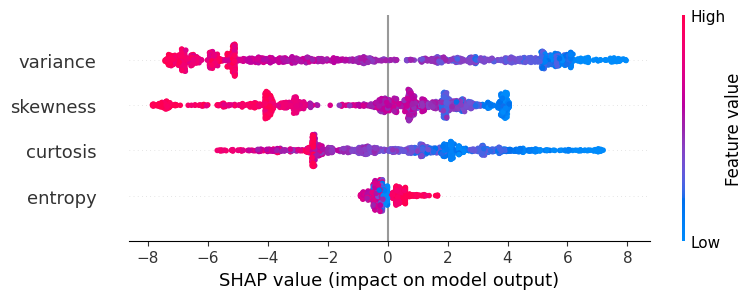

In [5]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
import shap

# Load the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"
names = ['variance', 'skewness', 'curtosis', 'entropy', 'class']
data = pd.read_csv(url, names=names)
X, y = data.iloc[:, :-1], data.iloc[:, -1]

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train an XGBoost model
model = xgb.XGBClassifier()
model.fit(X_train, y_train)

# Compute and display feature importances
importances = model.feature_importances_
print("Feature importances:")
for name, importance in zip(X.columns, importances):
    print(f"{name}: {importance}")

# Compute and display SHAP values
explainer = shap.Explainer(model)
shap_values = explainer(X)

# Plot a summary plot for SHAP values
shap.summary_plot(shap_values, X)


# Calibración de Probabilidades

Los modelos de árboles (especialmente Random Forest y XGBoost) frecuentemente producen **probabilidades mal calibradas**. Es decir, cuando el modelo dice "70% de probabilidad de clase positiva", la proporción real de positivos no es necesariamente 70%.

Esto importa cuando:
- Las probabilidades se usan para **tomar decisiones** (ej: aprobar un crédito si P(pago) > 0.8)
- Se comparan probabilidades entre modelos diferentes
- Se necesitan **rankings confiables** (ej: priorizar pacientes por riesgo)

### Soluciones:
- **Platt Scaling**: Ajusta una regresión logística sobre las probabilidades del modelo → produce una curva sigmoide
- **Isotonic Regression**: Ajuste no paramétrico, más flexible pero necesita más datos

### ¿Por qué se descalibran las probabilidades?

| Modelo | Patrón de descalibración | Causas principales |
|---|---|---|
| **Random Forest** | Comprime al centro (nunca dice 0.01 o 0.99) | Promediar votos binarios de muchos árboles impide alcanzar extremos. Peor con pocos árboles (granularidad) o árboles poco profundos (hojas menos puras) |
| **XGBoost (overfit)** | Demasiado extremo (dice 0.99 cuando debería ser 0.75) | Demasiadas iteraciones sin early stopping o poca regularización: el modelo está "demasiado seguro" |
| **XGBoost (sobre-regularizado)** | Comprime al centro (similar a RF) | Learning rate muy bajo con pocas iteraciones, o `reg_lambda` muy alto: el modelo no converge y es "demasiado conservador" |
| **Cualquier modelo post-undersampling** | Sobreestima la clase minoritaria | Fue entrenado con proporciones artificiales (50/50 en vez de 99/1) |

**Referencias:**
- Niculescu-Mizil, A. & Caruana, R. (2005). Predicting Good Probabilities with Supervised Learning. *ICML 2005.*

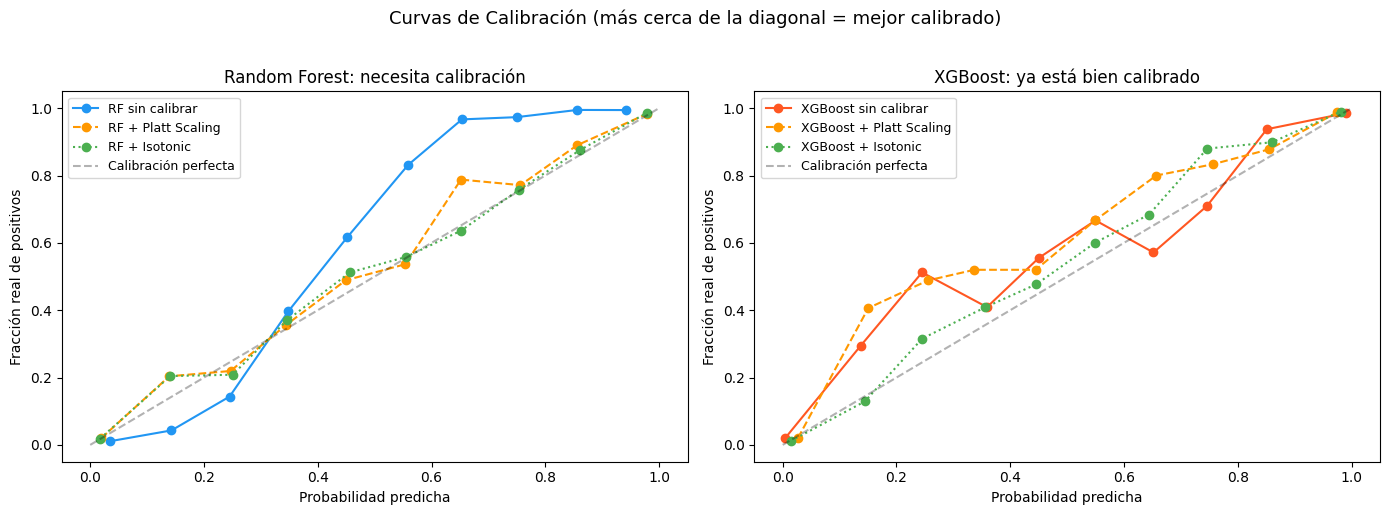

In [6]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import train_test_split
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

# Dataset sintético con desbalance 80/20
X, y = make_classification(n_samples=15000, n_features=20, n_informative=10,
                           n_classes=2, weights=[0.8, 0.2], random_state=42,
                           class_sep=1.0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Entrenar modelos
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

xgb_model = xgb.XGBClassifier(n_estimators=200, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Calibrar RF
rf_platt = CalibratedClassifierCV(rf, method='sigmoid', cv=5)
rf_platt.fit(X_train, y_train)

rf_isotonic = CalibratedClassifierCV(rf, method='isotonic', cv=5)
rf_isotonic.fit(X_train, y_train)

# Probabilidades
prob_rf = rf.predict_proba(X_test)[:, 1]
prob_rf_platt = rf_platt.predict_proba(X_test)[:, 1]
prob_rf_isotonic = rf_isotonic.predict_proba(X_test)[:, 1]
prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Curvas de calibración
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest: sin calibrar vs calibrado
ax = axes[0]
for probs, label, style, color in [
    (prob_rf, 'RF sin calibrar', '-', '#2196F3'),
    (prob_rf_platt, 'RF + Platt Scaling', '--', '#FF9800'),
    (prob_rf_isotonic, 'RF + Isotonic', ':', '#4CAF50'),
]:
    fraction_pos, mean_predicted = calibration_curve(y_test, probs, n_bins=10)
    ax.plot(mean_predicted, fraction_pos, style, marker='o', label=label, color=color)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Calibración perfecta')
ax.set_xlabel('Probabilidad predicha')
ax.set_ylabel('Fracción real de positivos')
ax.set_title('Random Forest: necesita calibración')
ax.legend(fontsize=9)

# XGBoost: sin calibrar vs calibrado
xgb_platt = CalibratedClassifierCV(xgb_model, method='sigmoid', cv=5)
xgb_platt.fit(X_train, y_train)

xgb_isotonic = CalibratedClassifierCV(xgb_model, method='isotonic', cv=5)
xgb_isotonic.fit(X_train, y_train)

prob_xgb_platt = xgb_platt.predict_proba(X_test)[:, 1]
prob_xgb_isotonic = xgb_isotonic.predict_proba(X_test)[:, 1]

ax = axes[1]
for probs, label, style, color in [
    (prob_xgb, 'XGBoost sin calibrar', '-', '#FF5722'),
    (prob_xgb_platt, 'XGBoost + Platt Scaling', '--', '#FF9800'),
    (prob_xgb_isotonic, 'XGBoost + Isotonic', ':', '#4CAF50'),
]:
    fraction_pos, mean_predicted = calibration_curve(y_test, probs, n_bins=10)
    ax.plot(mean_predicted, fraction_pos, style, marker='o', label=label, color=color)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Calibración perfecta')
ax.set_xlabel('Probabilidad predicha')
ax.set_ylabel('Fracción real de positivos')
ax.set_title('XGBoost: ya está bien calibrado')
ax.legend(fontsize=9)

plt.suptitle('Curvas de Calibración (más cerca de la diagonal = mejor calibrado)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


### Brier Score

Para medir numéricamente la calidad de la calibración, usamos el **Brier Score** — el error cuadrático medio de las probabilidades:

$$\text{Brier Score} = \frac{1}{n} \sum_{i=1}^{n} (p_i - y_i)^2$$

Donde $p_i$ es la probabilidad predicha y $y_i$ es el resultado real (0 o 1).

- **Brier = 0**: probabilidades perfectas
- **Brier = 0.25**: equivalente a predecir 0.5 para todo (no sabe nada)
- **Brier = 1**: probabilidades perfectamente invertidas

A diferencia de accuracy o F1 (que evalúan la clasificación), el Brier Score evalúa **la calidad de las probabilidades en sí mismas**.

In [7]:
# Brier Score
print("Brier Score (menor es mejor):")
print("=" * 55)
print(f"  {'Modelo':<30s} {'Brier Score':>12}")
print(f"  {'-'*42}")
print(f"  {'RF sin calibrar':<30s} {brier_score_loss(y_test, prob_rf):>12.4f}")
print(f"  {'RF + Platt Scaling':<30s} {brier_score_loss(y_test, prob_rf_platt):>12.4f}")
print(f"  {'RF + Isotonic Regression':<30s} {brier_score_loss(y_test, prob_rf_isotonic):>12.4f}")
print(f"  {'XGBoost sin calibrar':<30s} {brier_score_loss(y_test, prob_xgb):>12.4f}")
print(f"  {'XGBoost + Platt Scaling':<30s} {brier_score_loss(y_test, prob_xgb_platt):>12.4f}")
print(f"  {'XGBoost + Isotonic':<30s} {brier_score_loss(y_test, prob_xgb_isotonic):>12.4f}")

Brier Score (menor es mejor):
  Modelo                          Brier Score
  ------------------------------------------
  RF sin calibrar                      0.0469
  RF + Platt Scaling                   0.0378
  RF + Isotonic Regression             0.0376
  XGBoost sin calibrar                 0.0308
  XGBoost + Platt Scaling              0.0314
  XGBoost + Isotonic                   0.0287


# Imbalanced problems

### Problemas de clasificación

Soluciones: agregar pesos, undersampling, SMOTE, oversampling:

In [8]:
import numpy as np
import xgboost as xgb
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.utils import class_weight
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.pipeline import Pipeline
import time

# Crear dataset desbalanceado (99/1)
X, y = make_classification(n_samples=1000000, n_features=5, n_classes=2,
                           weights=[0.99, 0.01], random_state=42, class_sep=0.5)

# Agregar ruido a la clase mayoritaria
noise_indices = np.random.choice(np.where(y == 0)[0], size=int(0.2 * np.sum(y == 0)), replace=False)
X[noise_indices, :] += np.random.normal(0, 2, size=(len(noise_indices), X.shape[1]))

ratio = float(np.sum(y == 0)) / np.sum(y == 1)
print(f'Ratio de desbalance: {ratio:.1f}:1')
print(f'Clase 0: {np.sum(y == 0):,} | Clase 1: {np.sum(y == 1):,}')

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Definir modelos y pipelines
models = {
    'Sin pesos': xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
    'scale_pos_weight': xgb.XGBClassifier(scale_pos_weight=ratio, random_state=42, eval_metric='logloss'),
    'Undersampling': Pipeline([
        ('undersample', RandomUnderSampler(sampling_strategy='majority')),
        ('clf', xgb.XGBClassifier(random_state=42, eval_metric='logloss'))]),
    'SMOTE': Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf', xgb.XGBClassifier(random_state=42, eval_metric='logloss'))]),
    'Oversampling': Pipeline([
        ('oversample', RandomOverSampler(random_state=42)),
        ('clf', xgb.XGBClassifier(random_state=42, eval_metric='logloss'))]),
}

# Evaluar cada modelo
print(f"\n{'Método':<20s} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'Tiempo':>10}")
print(f"{'-'*60}")

for name, model in models.items():
    start = time.time()
    precision = np.mean(cross_val_score(model, X, y, scoring='precision', cv=cv))
    recall = np.mean(cross_val_score(model, X, y, scoring='recall', cv=cv))
    f1 = np.mean(cross_val_score(model, X, y, scoring='f1', cv=cv))
    elapsed = time.time() - start
    print(f"{name:<20s} {precision:>10.3f} {recall:>10.3f} {f1:>10.3f} {elapsed:>9.1f}s")


Ratio de desbalance: 66.6:1
Clase 0: 985,207 | Clase 1: 14,793

Método                Precision     Recall   F1-Score     Tiempo
------------------------------------------------------------


Sin pesos                 0.788      0.277      0.410       8.0s


scale_pos_weight          0.123      0.665      0.207       8.2s


Undersampling             0.093      0.685      0.165       3.1s


SMOTE                     0.120      0.670      0.204      16.0s


Oversampling              0.125      0.666      0.210      16.0s


### Problemas de regresión:

Usando inverse probability weighting:

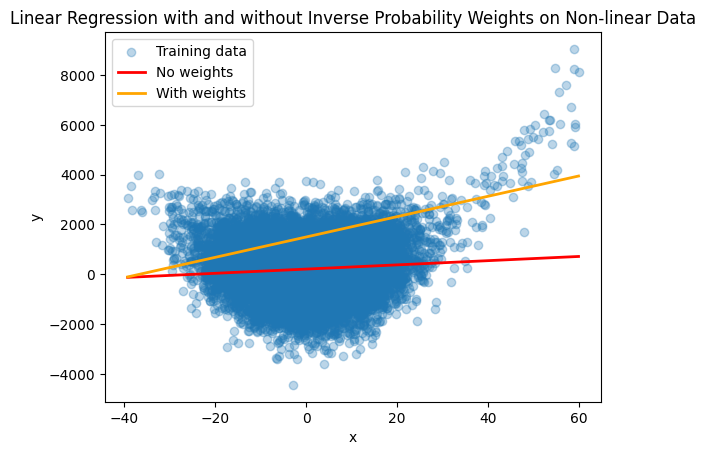

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from scipy.stats import gaussian_kde

# Step 1: Generate the dataset
np.random.seed(42)
x = np.concatenate([np.random.normal(0, 10, 20000), np.random.uniform(60, 30, 100)])
y = (2 * x**2 + 3) + np.random.normal(0, 1000, size=x.shape)

# Step 2: Split the dataset
x_train, x_test, y_train, y_test = train_test_split(x.reshape(-1, 1), y, test_size=0.2, random_state=42)

# Step 3: Train a model without sample weights
lr_no_weights = LinearRegression()
lr_no_weights.fit(x_train, y_train)

# Step 4: Train a model with sample weights
kde = gaussian_kde(x_train.flatten())
probability_density = kde(x_train.flatten())
sample_weights = 1 / (probability_density)

lr_weights = LinearRegression()
lr_weights.fit(x_train, y_train, sample_weight=sample_weights)

# Step 5: Plot the predictions
x_plot = np.linspace(x.min(), x.max(), 1000).reshape(-1, 1)
y_no_weights = lr_no_weights.predict(x_plot)
y_weights = lr_weights.predict(x_plot)

plt.scatter(x_train, y_train, alpha=0.3, label="Training data")
plt.plot(x_plot, y_no_weights, label="No weights", linewidth=2, color='r')
plt.plot(x_plot, y_weights, label="With weights", linewidth=2, color='orange')
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression with and without Inverse Probability Weights on Non-linear Data")
plt.show()

# Corrección de Probabilidades después de Undersampling

Cuando hacemos **undersampling** de la clase mayoritaria, cambiamos artificialmente la proporción de clases. El modelo aprende con estas proporciones artificiales, por lo que sus probabilidades estimadas están **sesgadas**.

Por ejemplo, si en los datos originales el 1% es fraude, pero después de undersampling el 50% es fraude, el modelo sobreestimará la probabilidad de fraude.

### La corrección

Sea:
- $\beta_s$ = proporción de positivos en los datos con undersampling (ej: 0.50)
- $\beta_o$ = proporción de positivos en los datos originales (ej: 0.01)
- $p_s$ = probabilidad estimada por el modelo (entrenado con undersampling)

La probabilidad corregida es:

$$p_{corregida} = \frac{p_s \cdot \frac{\beta_o}{\beta_s}}{p_s \cdot \frac{\beta_o}{\beta_s} + (1 - p_s) \cdot \frac{1 - \beta_o}{1 - \beta_s}}$$

Esta fórmula viene directamente del **teorema de Bayes**: ajusta las probabilidades del modelo para reflejar las proporciones reales de la población.

In [10]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from imblearn.under_sampling import RandomUnderSampler
import matplotlib.pyplot as plt

# Crear dataset muy desbalanceado (1% positivo)
X, y = make_classification(n_samples=20000, n_features=10, n_classes=2,
                           weights=[0.99, 0.01], random_state=42, class_sep=1.0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

proporcion_original = y_train.mean()
print(f"Proporción de positivos en datos originales: {proporcion_original:.3f} ({proporcion_original:.1%})")

# Aplicar undersampling
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

proporcion_under = y_train_under.mean()
print(f"Proporción de positivos después de undersampling: {proporcion_under:.3f} ({proporcion_under:.1%})")
print(f"Tamaño original: {len(y_train)} → Undersampling: {len(y_train_under)}")

Proporción de positivos en datos originales: 0.016 (1.6%)
Proporción de positivos después de undersampling: 0.500 (50.0%)
Tamaño original: 14000 → Undersampling: 448


In [11]:
# Entrenar modelo con datos de undersampling
model = xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
model.fit(X_train_under, y_train_under)

# Probabilidades sin corregir (sesgadas)
probs_uncorrected = model.predict_proba(X_test)[:, 1]

# Función de corrección
def correct_undersampling_probs(p_sampled, beta_original, beta_sampled):
    """
    Corrige las probabilidades estimadas por un modelo entrenado con undersampling.
    
    p_sampled:      probabilidades del modelo (entrenado con datos submuestreados)
    beta_original:  proporción de positivos en los datos originales
    beta_sampled:   proporción de positivos en los datos submuestreados
    """
    numerator = p_sampled * (beta_original / beta_sampled)
    denominator = numerator + (1 - p_sampled) * ((1 - beta_original) / (1 - beta_sampled))
    return numerator / denominator

# Aplicar corrección
probs_corrected = correct_undersampling_probs(probs_uncorrected, proporcion_original, proporcion_under)

print(f"Probabilidades sin corregir — Media: {probs_uncorrected.mean():.3f}  (debería estar cerca de {proporcion_original:.3f})")
print(f"Probabilidades corregidas  — Media: {probs_corrected.mean():.3f}  (debería estar cerca de {proporcion_original:.3f})")
print(f"Proporción real en test:   — {y_test.mean():.3f}")

Probabilidades sin corregir — Media: 0.234  (debería estar cerca de 0.016)
Probabilidades corregidas  — Media: 0.028  (debería estar cerca de 0.016)
Proporción real en test:   — 0.015


# Paralelización:

Se puede paralelizar en los distintos cores del computador. Para computadores con tarjeta de video NVIDIA, se puede usar la GPU:

In [12]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import xgboost as xgb
import time

# Cargar dataset Covertype (grande, para medir tiempos)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/covtype/covtype.data.gz"
data = pd.read_csv(url, header=None)
data = data.loc[0:500000,]

# Preparar datos
X, y = data.iloc[:, :-1], data.iloc[:, -1]
y = y - 1

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Sin paralelización (1 core CPU)
print("Entrenando sin paralelización (1 core CPU)...")
start_time = time.time()
model_1core = xgb.XGBClassifier(objective='multi:softmax', num_class=7, n_jobs=1,
                                 tree_method='hist', device='cpu',
                                 n_estimators=100, random_state=42, eval_metric='mlogloss')
model_1core.fit(X_train, y_train)
time_1core = time.time() - start_time

# 2. Con paralelización CPU (todos los cores)
print("Entrenando con paralelización CPU (todos los cores)...")
start_time = time.time()
model_parallel = xgb.XGBClassifier(objective='multi:softmax', num_class=7, n_jobs=-1,
                                    tree_method='hist', device='cpu',
                                    n_estimators=100, random_state=42, eval_metric='mlogloss')
model_parallel.fit(X_train, y_train)
time_parallel = time.time() - start_time

# Comparar tiempos
print(f"\n{'Método':<35s} {'Tiempo':>10} {'Speedup':>10}")
print(f"{'-'*55}")
print(f"{'CPU (1 core)':<35s} {time_1core:>9.2f}s {'1.0x':>10}")
print(f"{'CPU (todos los cores, n_jobs=-1)':<35s} {time_parallel:>9.2f}s {time_1core/time_parallel:>9.1f}x")
print()
print("Nota: XGBoost también soporta GPU con device='cuda' para tarjetas NVIDIA,")
print("lo cual puede dar speedups de 10-50x en datasets grandes.")
print("Apple Silicon (M1-M5) no es compatible con CUDA — para GPU en Mac.")

Entrenando sin paralelización (1 core CPU)...


Entrenando con paralelización CPU (todos los cores)...



Método                                  Tiempo    Speedup
-------------------------------------------------------
CPU (1 core)                            13.40s       1.0x
CPU (todos los cores, n_jobs=-1)         4.85s       2.8x

Nota: XGBoost también soporta GPU con device='cuda' para tarjetas NVIDIA,
lo cual puede dar speedups de 10-50x en datasets grandes.
Apple Silicon (M1-M5) no es compatible con CUDA — para GPU en Mac.
